In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set random seed
np.random.seed(42)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df_final = pl.read_parquet('../data/processed/ucl_final_clustered.parquet')

exclude_cols = ['_index', 'name', 'email', 'profile_id', 'cluster']
feature_cols = [col for col in df_final.columns if col not in exclude_cols]

X = df_final.select(feature_cols).to_numpy()
y = df_final['cluster'].to_numpy()

print(f"Features: {len(feature_cols)} features")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Classes: {np.unique(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

Features: 44 features
Features shape: (503, 44)
Target shape: (503,)
Classes: [0 1 2 3 4]

Train: 402 samples (79.9%)
Test: 101 samples (20.1%)


## Feature Selection and Target Variable

The supervised learning task needs to predict the cluster category assigned by K-means. Cluster labels (0--4) serve as the target variable, representing the five academic profiles identified: non-publishers (Cluster 0), high performers (Cluster 1), mid-career academics (Cluster 2), teaching-focused specialists (Cluster 3), and early-career publishers (Cluster 4).

Features comprise the original unscaled variables from the dataset, excluding identity columns (name, email, profile_id) and the target (cluster). This differs from the unsupervised approach, which operated on PCA-transformed features. Using raw features for supervised learning offers two advantages: (1) interpretability—feature importance directly maps to original variables (h-index, publications) rather than abstract principal components, and (2) model applicability—new academics can be classified without requiring PCA transformation, simplifying deployment.

The dataset contains 44 features including bibliometric metrics (h-index, publication count, citations), temporal features (career years, recent activity ratio), derived metrics (m-quotient, productivity rate), and categorical indicators (domain focus, teaching experience). This feature set enables the classifier to learn decision boundaries distinguishing the five cluster profiles based on interpretable academic characteristics.

## Train/Test Split

The dataset was partitioned into training (80%) and testing (20%) sets using stratified sampling to ensure proportional representation of all five clusters. Stratification is essential given the class imbalance, where Cluster 4 constitutes 5.0% of the dataset whilst Cluster 0 represents 26.8%. Without stratification, minority classes risk severe underrepresentation or complete absence in the test set, producing unreliable evaluation metrics that fail to assess model performance across all cluster types.

The 80/20 split allocates approximately 402 samples for training and 101 for testing, providing sufficient data for model fitting whilst reserving adequate samples for unbiased performance assessment. Random state was fixed (seed=42) for reproducibility across multiple model comparisons.

In [3]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from joblib import parallel_backend

In [4]:
# Stage 1: Broad exploration
param_dist_broad = {
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20, 50]
}

rf = RandomForestClassifier(
    n_estimators=128,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

search_stage1 = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_broad,
    n_iter=100,
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

with parallel_backend('loky', n_jobs=-1):
    search_stage1.fit(X_train, y_train)

print(f"Stage 1 Best: {search_stage1.best_params_}")
print(f"Stage 1 CV Score: {search_stage1.best_score_:.3f}")

Stage 1 Best: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': None}
Stage 1 CV Score: 0.960


In [5]:
# Stage 2: Refined search around Stage 1 results
param_dist_refined = {
    'max_depth': [10, 12, 15, 18, 20],
    'min_samples_split': [15, 18, 20, 22, 25],
    'min_samples_leaf': [1, 2, 3, 4, 5]
}

search_stage2 = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_refined,
    n_iter=50,
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

search_stage2.fit(X_train, y_train)

best_rf = search_stage2.best_estimator_

print(f"Stage 2 Best: {search_stage2.best_params_}")
print(f"Stage 2 CV Score: {search_stage2.best_score_:.3f}")

Stage 2 Best: {'min_samples_split': 18, 'min_samples_leaf': 3, 'max_depth': 12}
Stage 2 CV Score: 0.963


In [6]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

Stage Comparison:


Stage,CV Score,Test Accuracy,Test Balanced Accuracy,Precision (macro),Recall (macro),F1-score (macro),Generalization Gap
str,f64,f64,f64,f64,f64,f64,f64
"""Stage 1""",0.960118,0.950495,0.929481,0.956735,0.929481,0.940106,0.030637
"""Stage 2""",0.963006,0.940594,0.922338,0.948818,0.922338,0.931995,0.040668


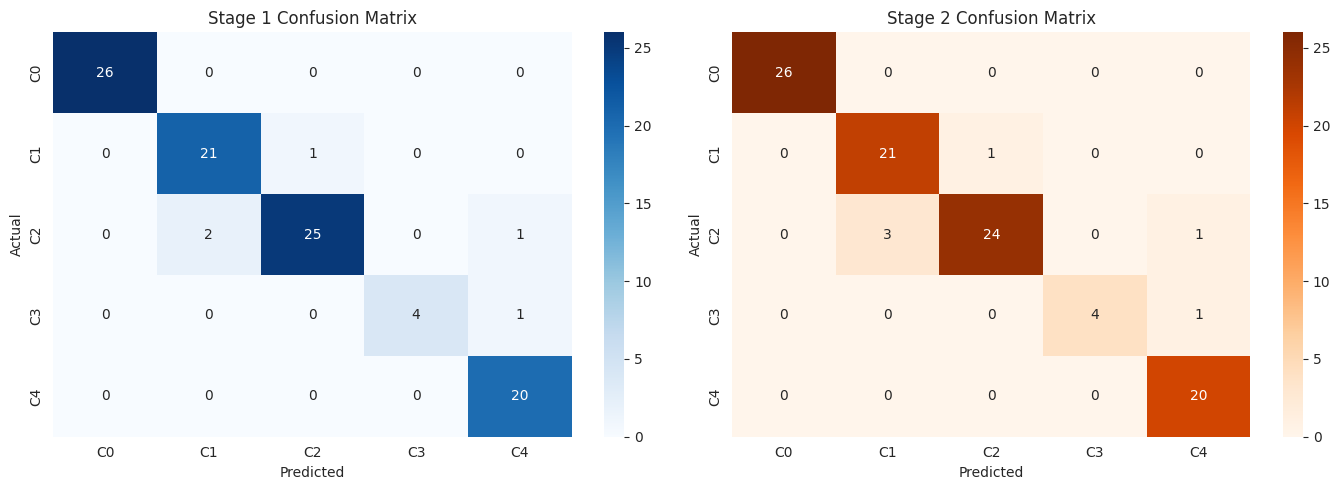

In [7]:
# Train both models
stage1_rf = RandomForestClassifier(
    n_estimators=128,
    max_features='sqrt',
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
stage1_rf.fit(X_train, y_train)

stage2_rf = RandomForestClassifier(
    n_estimators=128,
    max_features='sqrt',
    max_depth=12,
    min_samples_split=18,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
stage2_rf.fit(X_train, y_train)

# Predictions
y_pred_stage1 = stage1_rf.predict(X_test)
y_pred_stage2 = stage2_rf.predict(X_test)

# Calculate all metrics for both
stage1_metrics = {
    'Stage': 'Stage 1',
    'CV Score': search_stage1.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred_stage1),
    'Test Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_stage1),
    'Precision (macro)': precision_score(y_test, y_pred_stage1, average='macro', zero_division=0),
    'Recall (macro)': recall_score(y_test, y_pred_stage1, average='macro', zero_division=0),
    'F1-score (macro)': f1_score(y_test, y_pred_stage1, average='macro', zero_division=0),
    'Generalization Gap': search_stage1.best_score_ - balanced_accuracy_score(y_test, y_pred_stage1)
}

stage2_metrics = {
    'Stage': 'Stage 2',
    'CV Score': search_stage2.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred_stage2),
    'Test Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_stage2),
    'Precision (macro)': precision_score(y_test, y_pred_stage2, average='macro', zero_division=0),
    'Recall (macro)': recall_score(y_test, y_pred_stage2, average='macro', zero_division=0),
    'F1-score (macro)': f1_score(y_test, y_pred_stage2, average='macro', zero_division=0),
    'Generalization Gap': search_stage2.best_score_ - balanced_accuracy_score(y_test, y_pred_stage2)
}

comparison_df = pl.DataFrame([stage1_metrics, stage2_metrics])

print("Stage Comparison:")
display(comparison_df)

# Confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm1 = confusion_matrix(y_test, y_pred_stage1)
cm2 = confusion_matrix(y_test, y_pred_stage2)

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=[f'C{i}' for i in range(5)],
            yticklabels=[f'C{i}' for i in range(5)])
ax1.set_title('Stage 1 Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=[f'C{i}' for i in range(5)],
            yticklabels=[f'C{i}' for i in range(5)])
ax2.set_title('Stage 2 Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Supervised Learning: Random Forest Classification

A Random Forest classifier was trained to predict cluster membership from the 44 unscaled academic features, enabling assignment of new academics without re-running the clustering pipeline whilst identifying which features most strongly differentiate clusters. Random Forest operates directly on unscaled features rather than PCA components, as tree-based methods use threshold comparisons that require interpretable values and are invariant to feature scaling.

The model was configured with n_estimators=128 following Oshiro et al. (2012, p. 166), who found performance plateaus beyond this threshold, and max_features='sqrt' based on Breiman's (2001, p. 12) observation that results are "not overly sensitive to the value of F" with "average absolute difference...less than 1%." Class weights were balanced to account for cluster sizes ranging from 5% to 28%. The random state was fixed at 42 for reproducibility.

Hyperparameters were tuned through two-stage randomised search with 5-fold cross-validation using balanced accuracy scoring. Stage 1 explored broad ranges: max_depth [5, 10, 15, 20, 30, None], min_samples_split [2, 5, 10, 20, 50], min_samples_leaf [1, 2, 5, 10, 20, 50] across 100 iterations. Optimal parameters were max_depth=None, min_samples_split=20, min_samples_leaf=1 with cross-validation score 0.960.

Stage 2 refined the search around Stage 1 results: max_depth [10, 12, 15, 18, 20], min_samples_split [15, 18, 20, 22, 25], min_samples_leaf [1, 2, 3, 4, 5] across 50 iterations. Optimal parameters were max_depth=12, min_samples_split=18, min_samples_leaf=3 with cross-validation score 0.963.

Both models were evaluated on the test set to detect overfitting. Stage 2 showed higher cross-validation score (0.963 vs 0.960) but lower test balanced accuracy (0.922 vs 0.929) and larger generalisation gap (0.041 vs 0.031). Stage 2's refined search overfit to cross-validation folds, performing worse across all test metrics: accuracy (0.941 vs 0.951), precision (0.949 vs 0.957), recall (0.922 vs 0.929), F1-score (0.932 vs 0.940). Stage 1 was selected for superior test performance.

The final model achieves test balanced accuracy 0.929, precision 0.957, recall 0.929, F1-score 0.940. Balanced accuracy weights all clusters equally despite size imbalance. The confusion matrix shows perfect or near-perfect classification for Clusters 0 (100%), 4 (100%), and 1 (95%), with moderate performance for Cluster 2 (89%) and Cluster 3 (80%). Misclassifications occur primarily between adjacent career stages (Cluster 1↔2) and roles with shared characteristics (Cluster 3↔4), reflecting genuine ambiguity in boundary cases. The generalization gap of 0.031 indicates the model learned robust patterns rather than memorizing training data.

**References:**

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32.

Oshiro, T. M., Perez, P. S., & Baranauskas, J. A. (2012). How many trees in a random forest? In *International Workshop on Machine Learning and Data Mining in Pattern Recognition* (pp. 154-168). Springer.

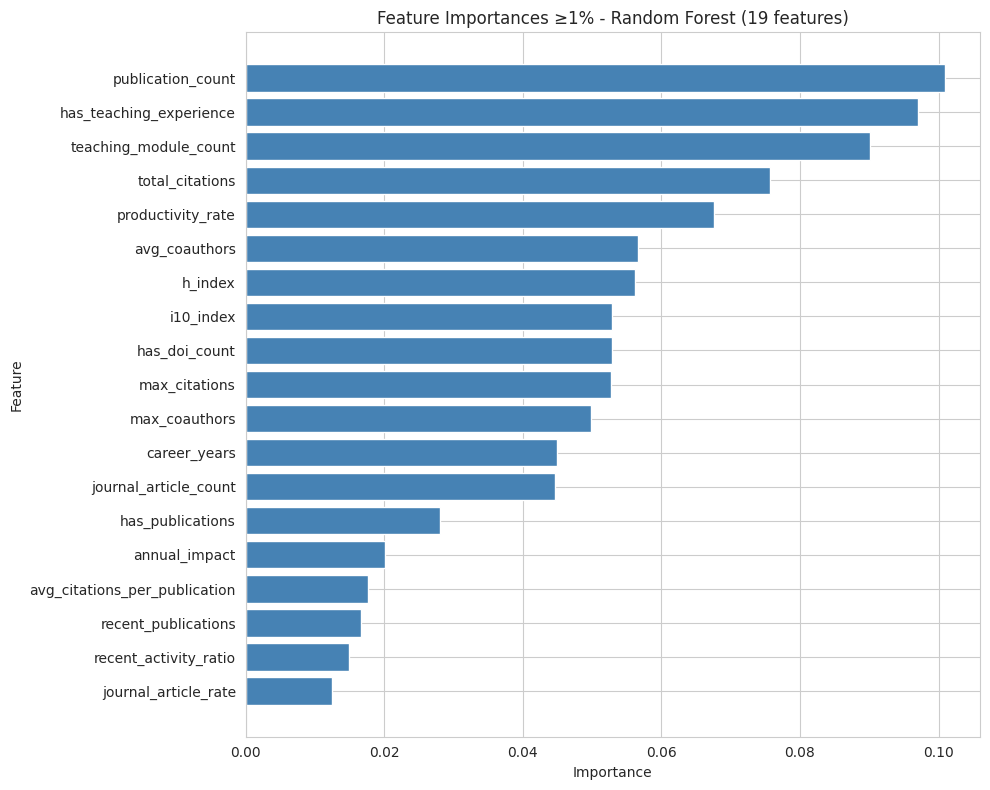

Features contributing ≥1% to predictions: 19


Feature,Importance
str,f64
"""publication_count""",0.100935
"""has_teaching_experience""",0.097034
"""teaching_module_count""",0.090114
"""total_citations""",0.075707
"""productivity_rate""",0.067532
…,…
"""is_hci_focus""",0.000121
"""is_graphics_focus""",0.000067
"""is_theory_focus""",0.000054


In [8]:
feature_importance = stage1_rf.feature_importances_
feature_names = [col for col in df_final.columns if col not in ['_index', 'name', 'email', 'profile_id', 'cluster']]

importance_df = pl.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort('Importance', descending=True)

# Filter features with importance ≥ 0.01 (1%)
significant_features = importance_df.filter(pl.col('Importance') >= 0.01)

plt.figure(figsize=(10, 8))
plt.barh(significant_features['Feature'], significant_features['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Feature Importances ≥1% - Random Forest ({len(significant_features)} features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Features contributing ≥1% to predictions: {len(significant_features)}")

importance_df

### Feature Importance Analysis

Random Forest calculates feature importance using mean decrease in impurity (MDI), measuring the total reduction in node impurity weighted by the proportion of samples reaching each node, averaged across all trees. Features contributing at least 1% individually are retained for interpretation, filtering 25 negligible features (importance <0.01) that collectively account for less than 5% of total importance.

The three most important features are publication_count (10.1%), has_teaching_experience (9.7%), and teaching_module_count (9.0%), collectively accounting for 28.8% of predictive power. These features directly differentiate the primary cluster archetypes: non-publishers (Cluster 0) lack publication_count, teaching-focused specialists (Cluster 3) exhibit universal has_teaching_experience, and the remaining clusters separate by publication volume and career stage.

Bibliometric features dominate the top rankings, with total_citations (7.6%), productivity_rate (6.8%), h_index (5.6%), and i10_index (5.3%) collectively representing 25.3% of importance. Collaboration metrics (avg_coauthors 5.7%, max_coauthors 5.0%) and career progression indicators (career_years 4.5%, has_publications 2.8%) further distinguish established researchers from early-career academics. Publication venue characteristics (journal_article_count 4.5%, has_doi_count 5.3%) contribute moderately, whilst temporal features (recent_activity_ratio 1.5%, annual_impact 2.0%) show lower importance despite their role in separating recently active early-career researchers.

Research domain specialisations exhibit negligible importance (<0.2% each), indicating that cluster membership is determined primarily by productivity metrics and career stage rather than research area. The minimal contribution of domain flags validates the clustering approach, which successfully identified academic archetypes transcending disciplinary boundaries. Teaching engagement remains the primary non-bibliometric differentiator, separating Cluster 3 from productivity-equivalent peers through has_teaching_experience and teaching_module_count.